# Lectura de tonos en un telefono de linea
123
456
789
*0#

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

## Funcion procesadora de datos
    Procesa varias mediciones de una misma señal y calcula el
    espectro promedio RMS.

    Parámetros
    archivos : list[str]
        Lista de archivos CSV.
    dt : float
        Período de muestreo.
    
    Retorna
        tiempo                 -> vector temporal
        voltaje                -> señal temporal del primer archivo
        frecuencias            -> frecuencias positivas
        magnitud_db            -> FFT promedio RMS en dB
        magnitud               -> FFT promedio RMS en escala lineal
        top_4_picos            -> índices de los dos tonos principales mas los 2 parasitos
        frecuencia_picos       -> frecuencias de los tonos
        amplitud_picos_db      -> amplitudes en dB
        N                      -> cantidad de muestras

In [2]:
def procesar_mediciones(archivos, dt=1.00000e-04):

    N = None
    potencias = []

    tiempo = None
    voltaje = None

    for i, archivo in enumerate(archivos):

        df = pd.read_csv(
            archivo,
            skiprows=16, # Saltea informacion sobre el muestreo
            names=['Tiempo', 'Voltaje'],
            index_col=False
        )

        if N is None:
            N = len(df)

        # Guardo la primera señal para graficar y ver el efecto aliasing
        if i == 0:
            tiempo = df["Tiempo"].to_numpy()
            voltaje = df["Voltaje"].to_numpy()

        signal = df["Voltaje"].to_numpy()
        # Señal sin componente continua
        # Al eliminar la componente continua no se debe corregir al duplicarla 
        # con el resto de las frecuencias por sus respectivas componentes negativas.
        #signal = signal - np.mean(signal)

        # FFT
        fft_valores = fft(signal)
        mitad = N // 2
        magnitud = (2.0 / N) * np.abs(fft_valores[:mitad])

        # f=0 que no tiene componente "negativa" por la cual ser duplicada
        magnitud[0] = magnitud[0]/2           # DC
        if N % 2 == 0:
            magnitud[-1] /= 2      # Nyquist
            
        # Potencia
        potencias.append(magnitud**2)

    # Promedio RMS
    potencia_promedio = np.mean(potencias, axis=0)
    magnitud_promedio = np.sqrt(potencia_promedio)

    # Frecuencias
    frecuencias = fftfreq(N, dt)[:mitad]

    # dB
    magnitud_rms = magnitud_promedio / np.sqrt(2)
    magnitud_db = 20 * np.log10(np.clip(magnitud_rms, 1e-5, None))
    #magnitud_db = 20 * np.log10(np.clip(magnitud_promedio, 1e-5, None))

    # Se encuentran los picos y se los ordena en bajo y alto
    picos, _ = find_peaks(magnitud_db, distance=10)
    picos = picos[np.argsort(magnitud_db[picos])[::-1]]
    top_4 = picos[:4] # 2 tonos y 2 armonicos
    espuria = picos[4] # Quinto mayor pico

    # Piso de ruido (mediana de la FFT excluyendo los dos tonos y valores cercanos)
    mascara = np.ones(len(magnitud_db), dtype=bool)

    # Para el calculo de piso de ruido ignoro valores cercanos a los picos
    for indice in top_4:
        ini = max(0, indice - 5)
        fin = min(len(magnitud_db), indice + 6)
        mascara[ini:fin] = False

    piso_ruido_db = np.median(magnitud_db[mascara])

    return {
        "tiempo": tiempo,
        "voltaje": voltaje,
        "frecuencias": frecuencias,
        "magnitud": magnitud_promedio,
        "magnitud_db": magnitud_db,
        "top_4_picos": top_4,
        "frecuencia_picos": frecuencias[top_4],
        "amplitud_picos_db": magnitud_db[top_4],
        "piso_ruido_db": piso_ruido_db,
        "espuria_db": magnitud_db[espuria],
        "N": N
    }

Grafica la FFT con las coordenadas de los 2 picos maximos y el piso de ruido

In [3]:
def graficar_fft(resultado, titulo, ax):

    frecuencias = resultado["frecuencias"]
    magnitud_db = resultado["magnitud_db"]
    top_2_picos = resultado["top_4_picos"][:2]
    piso_ruido = resultado["piso_ruido_db"]

    ax.plot(
        frecuencias,
        magnitud_db,
        color="red",
        linewidth=1.2
    )

    ax.axhline( # Linea del piso de ruino
        piso_ruido,
        color="blue",
        linestyle="--",
        linewidth=1
    )

    ax.text( # Leyenda del piso de ruido
        0.98,
        0.03,
        f"Ruido: {piso_ruido:.1f} dB",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    # Se ordenan los tonos
    picos_ordenados = sorted(
        top_2_picos,
        key=lambda indice: frecuencias[indice]
    )

    for indice in picos_ordenados:

        freq = frecuencias[indice]
        amp = magnitud_db[indice]

        ax.scatter(freq, amp, s=25, color="blue")

        ax.annotate(
            f"{freq:.0f} Hz\n{amp:.1f} dB",
            (freq, amp),
            textcoords="offset points",
            xytext=(6,-6), # Distancia del texto al punto
            fontsize=12,
            bbox=dict(
                facecolor="gray", # Color de fondo (caja)
                alpha=0.3, # Transparencia
                edgecolor="none"
            )
        )

    ax.set_title(f"Tecla {titulo}", fontsize=12)
    ax.set_xlim(0, 2000)
    ax.grid(True, alpha=0.4)

## Codigo principal
Esta seccion declara las teclas y tonos nominales, y llama a las funciones de fft y graficos en ciclo para leer todos los archivos, procesarlos, promediarlos y graficarlos. Guarda los resultados para graficar o expresarlos en una tabla.

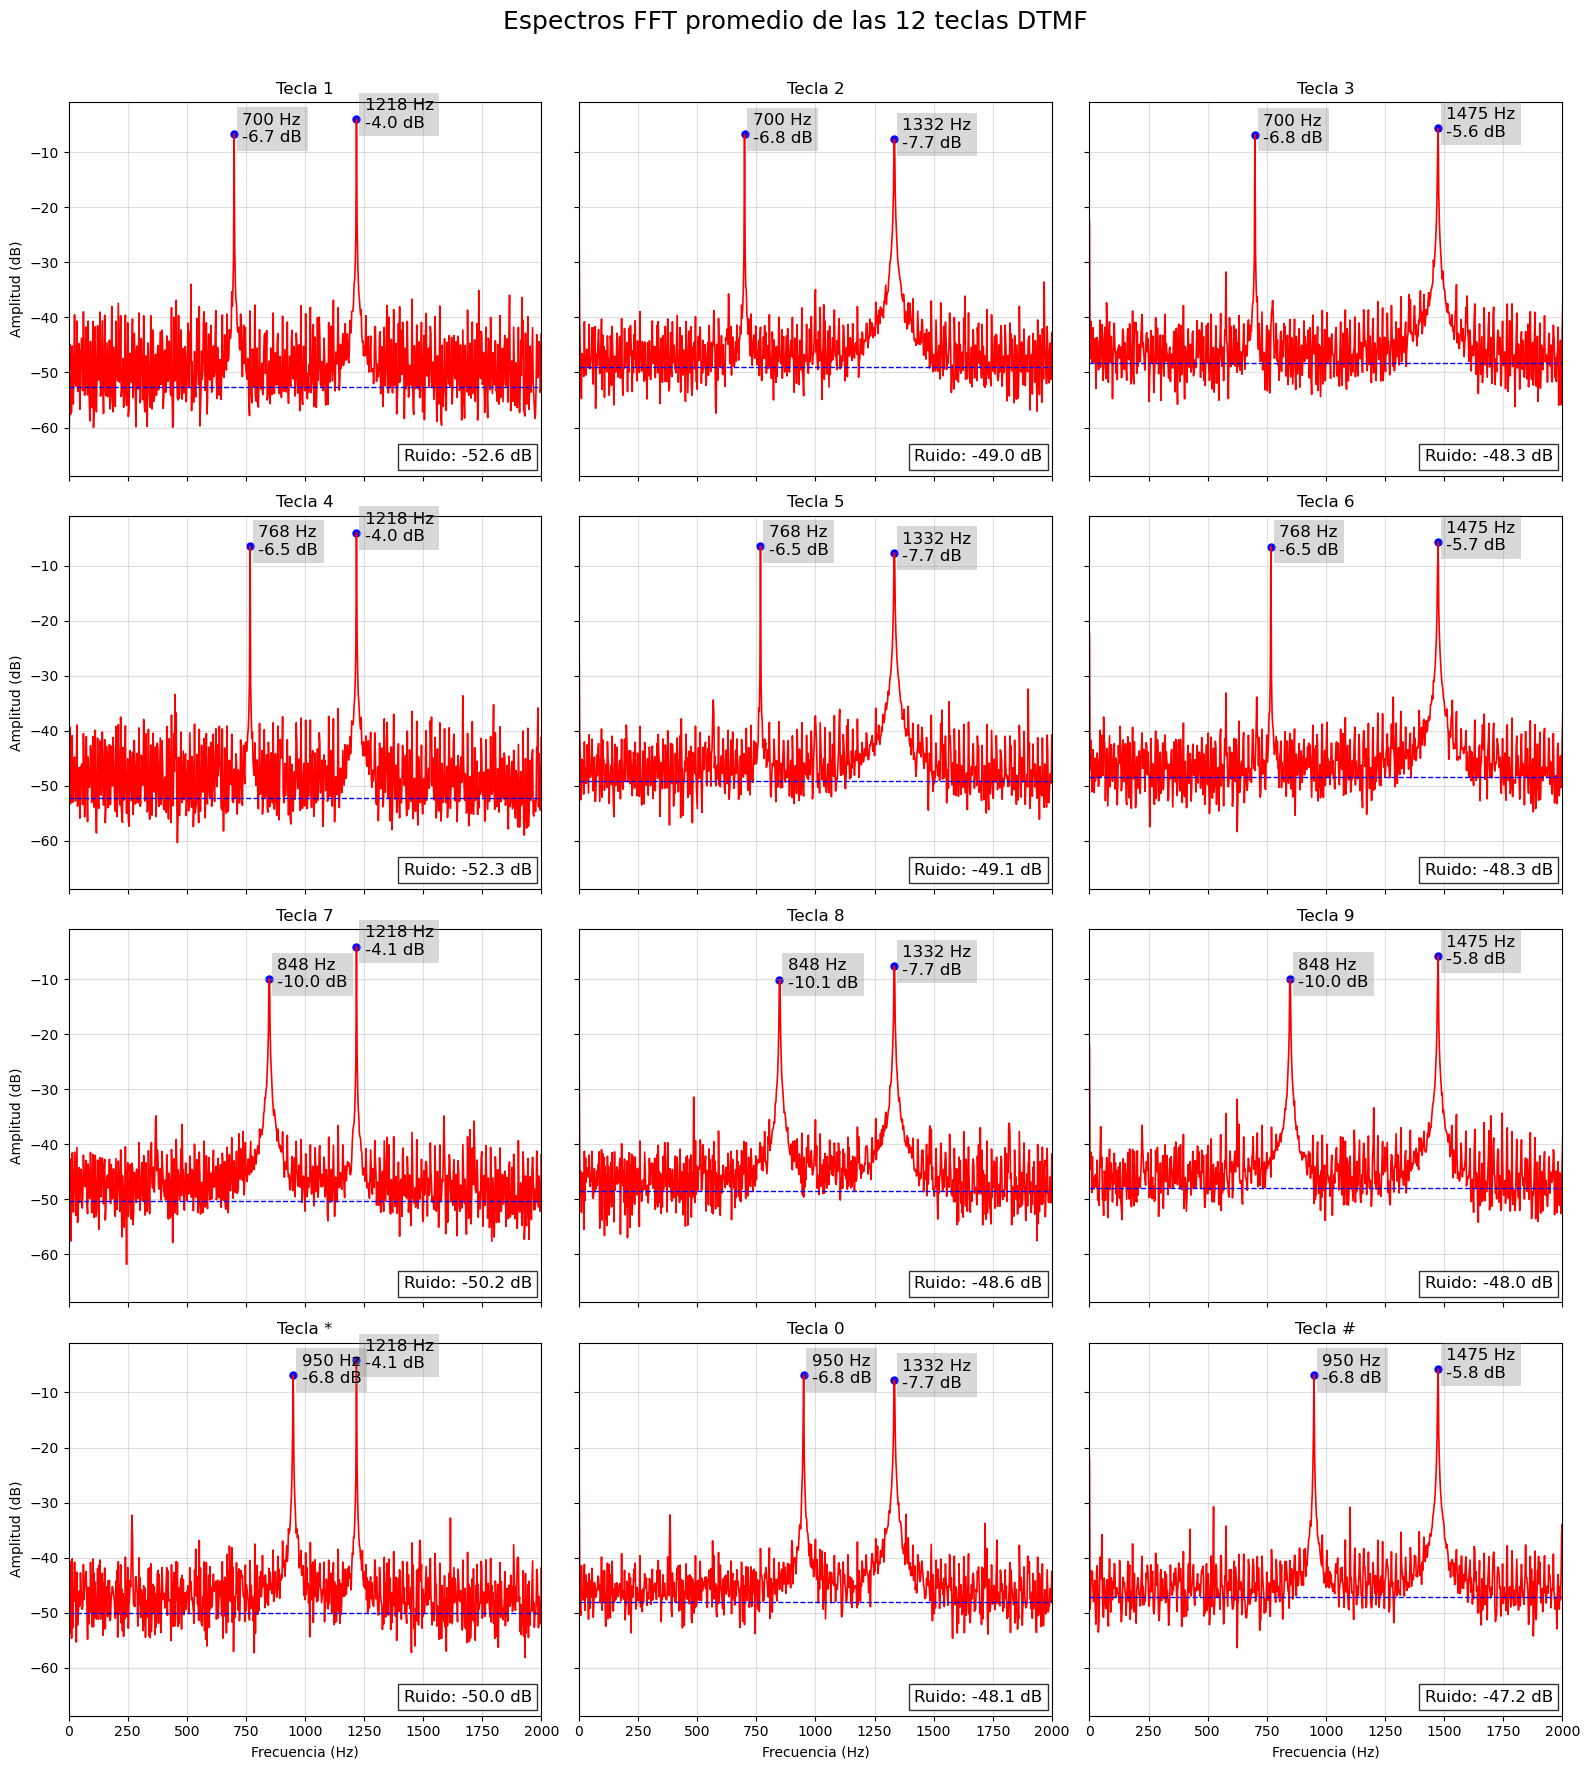

In [4]:
tono_columna = [1209, 1336, 1447]
tono_fila = [697, 770, 852, 941]

teclas = [
    ['1', '2', '3'],
    ['4', '5', '6'],
    ['7', '8', '9'],
    ['*', '0', '#']
]

resumen = []
resumen_db = []

fig, axs = plt.subplots(
    4,
    3,
    figsize=(16, 18),
    sharex=True,
    sharey=True
)

contador_archivo = 0

for fila, fila_teclas in enumerate(teclas):

    for columna, tecla in enumerate(fila_teclas):

        archivos = [
            f"medidas/DS{contador_archivo+i:04d}.CSV"
            for i in range(5)
        ]

        contador_archivo += 5

        resultado = procesar_mediciones(archivos)
        

        detectados = np.sort(resultado["frecuencia_picos"])
        esperados = np.sort([
            tono_fila[fila],
            tono_columna[columna]
        ])

        # Obtener los dos picos ordenados por frecuencia
        picos_ordenados = sorted(
            resultado["top_4_picos"],
            key=lambda i: resultado["frecuencias"][i]
        )
        picos = resultado["top_4_picos"]
        top_picos_db = resultado["magnitud_db"][picos]
        top_picos_hz = resultado["frecuencias"][picos]

        tono_bajo_db = resultado["magnitud_db"][picos_ordenados[0]]
        tono_alto_db = resultado["magnitud_db"][picos_ordenados[1]]

        # Calcular el piso de ruido
        mascara = np.ones(len(resultado["magnitud_db"]), dtype=bool)

        for indice in picos_ordenados:
            ini = max(0, indice - 5)
            fin = min(len(resultado["magnitud_db"]), indice + 6)
            mascara[ini:fin] = False

        piso_ruido = np.median(resultado["magnitud_db"][mascara])

        resumen.append([
            tecla,
            esperados[0],
            detectados[0],
            esperados[1],
            detectados[1]
        ])
        resumen_db.append([
            tecla,
            tono_bajo_db,
            tono_alto_db,
            piso_ruido,
            top_picos_db,
            top_picos_hz,
            resultado["espuria_db"]
        ])

        graficar_fft(
            resultado,
            tecla,
            axs[fila, columna]
        )

# Etiquetas sólo en los bordes
for ax in axs[-1, :]:
    ax.set_xlabel("Frecuencia (Hz)")

for ax in axs[:, 0]:
    ax.set_ylabel("Amplitud (dB)")

fig.suptitle(
    "Espectros FFT promedio de las 12 teclas DTMF",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Analisis de todo el espectro

En altas frecuencias, para todas las señales, aparecen 2 picos. Estos, aunque estrictamente pueden considerarse espurias, son armonicos. En realidad para el analisis conviene ignorar estas 2 "espurias" y tomar la tercera mayor, es decir, la verdadera espuria.
Ademas hay un analisis de PSD (densidad espectral de potencia) para verificar que el piso de ruido tenga sentido (me daba la sensacion de que estaba dando muy bajo, pero esta bien)

<Figure size 640x480 with 0 Axes>

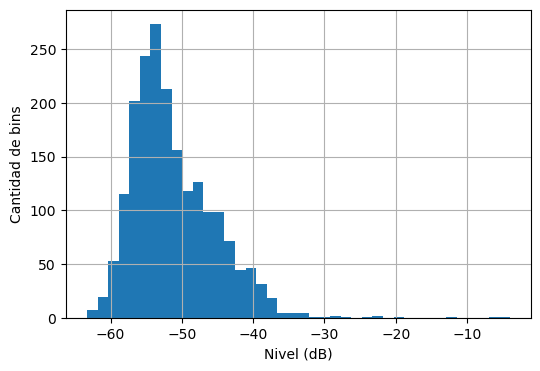

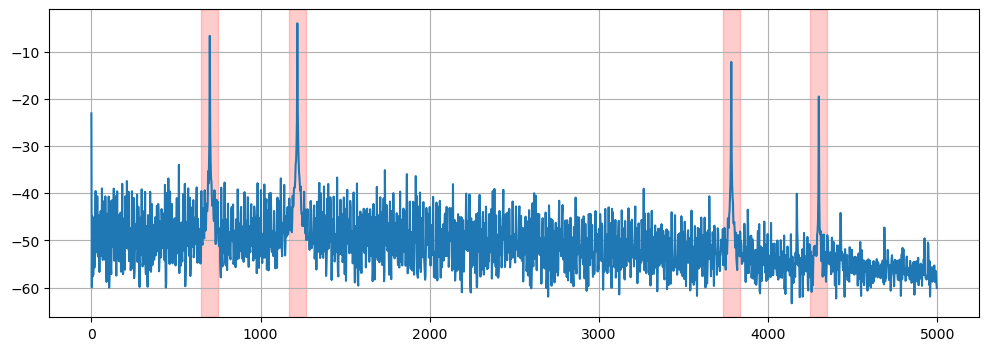

In [5]:
archivos = [
    f"medidas/DS{0+i:04d}.CSV"
    for i in range(5)
]

resultado = procesar_mediciones(archivos)

fig.suptitle(
    "Espectros FFT promedio de las 12 teclas DTMF",
    fontsize=18
)
top_4 = resultado["top_4_picos"]

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

plt.figure(figsize=(6,4))
plt.hist(resultado["magnitud_db"][mascara], bins=40)
plt.xlabel("Nivel (dB)")
plt.ylabel("Cantidad de bins")
plt.grid(True)

plt.figure(figsize=(12,4))
plt.plot(resultado["frecuencias"], resultado["magnitud_db"])

for indice in top_4:
    plt.axvspan(
        resultado["frecuencias"][max(0, indice-20)],
        resultado["frecuencias"][min(len(resultado["frecuencias"])-1, indice+20)],
        color="red",
        alpha=0.2
    )
plt.grid(True)

### Graficos en tiempo

Con el parametro division se deja como esta o reduce el eje en tiempo. La idea es capturar el efecto de alias (segun el profesor). Jugando con este parametro de division se deberia mejorar la visualizacion del alias

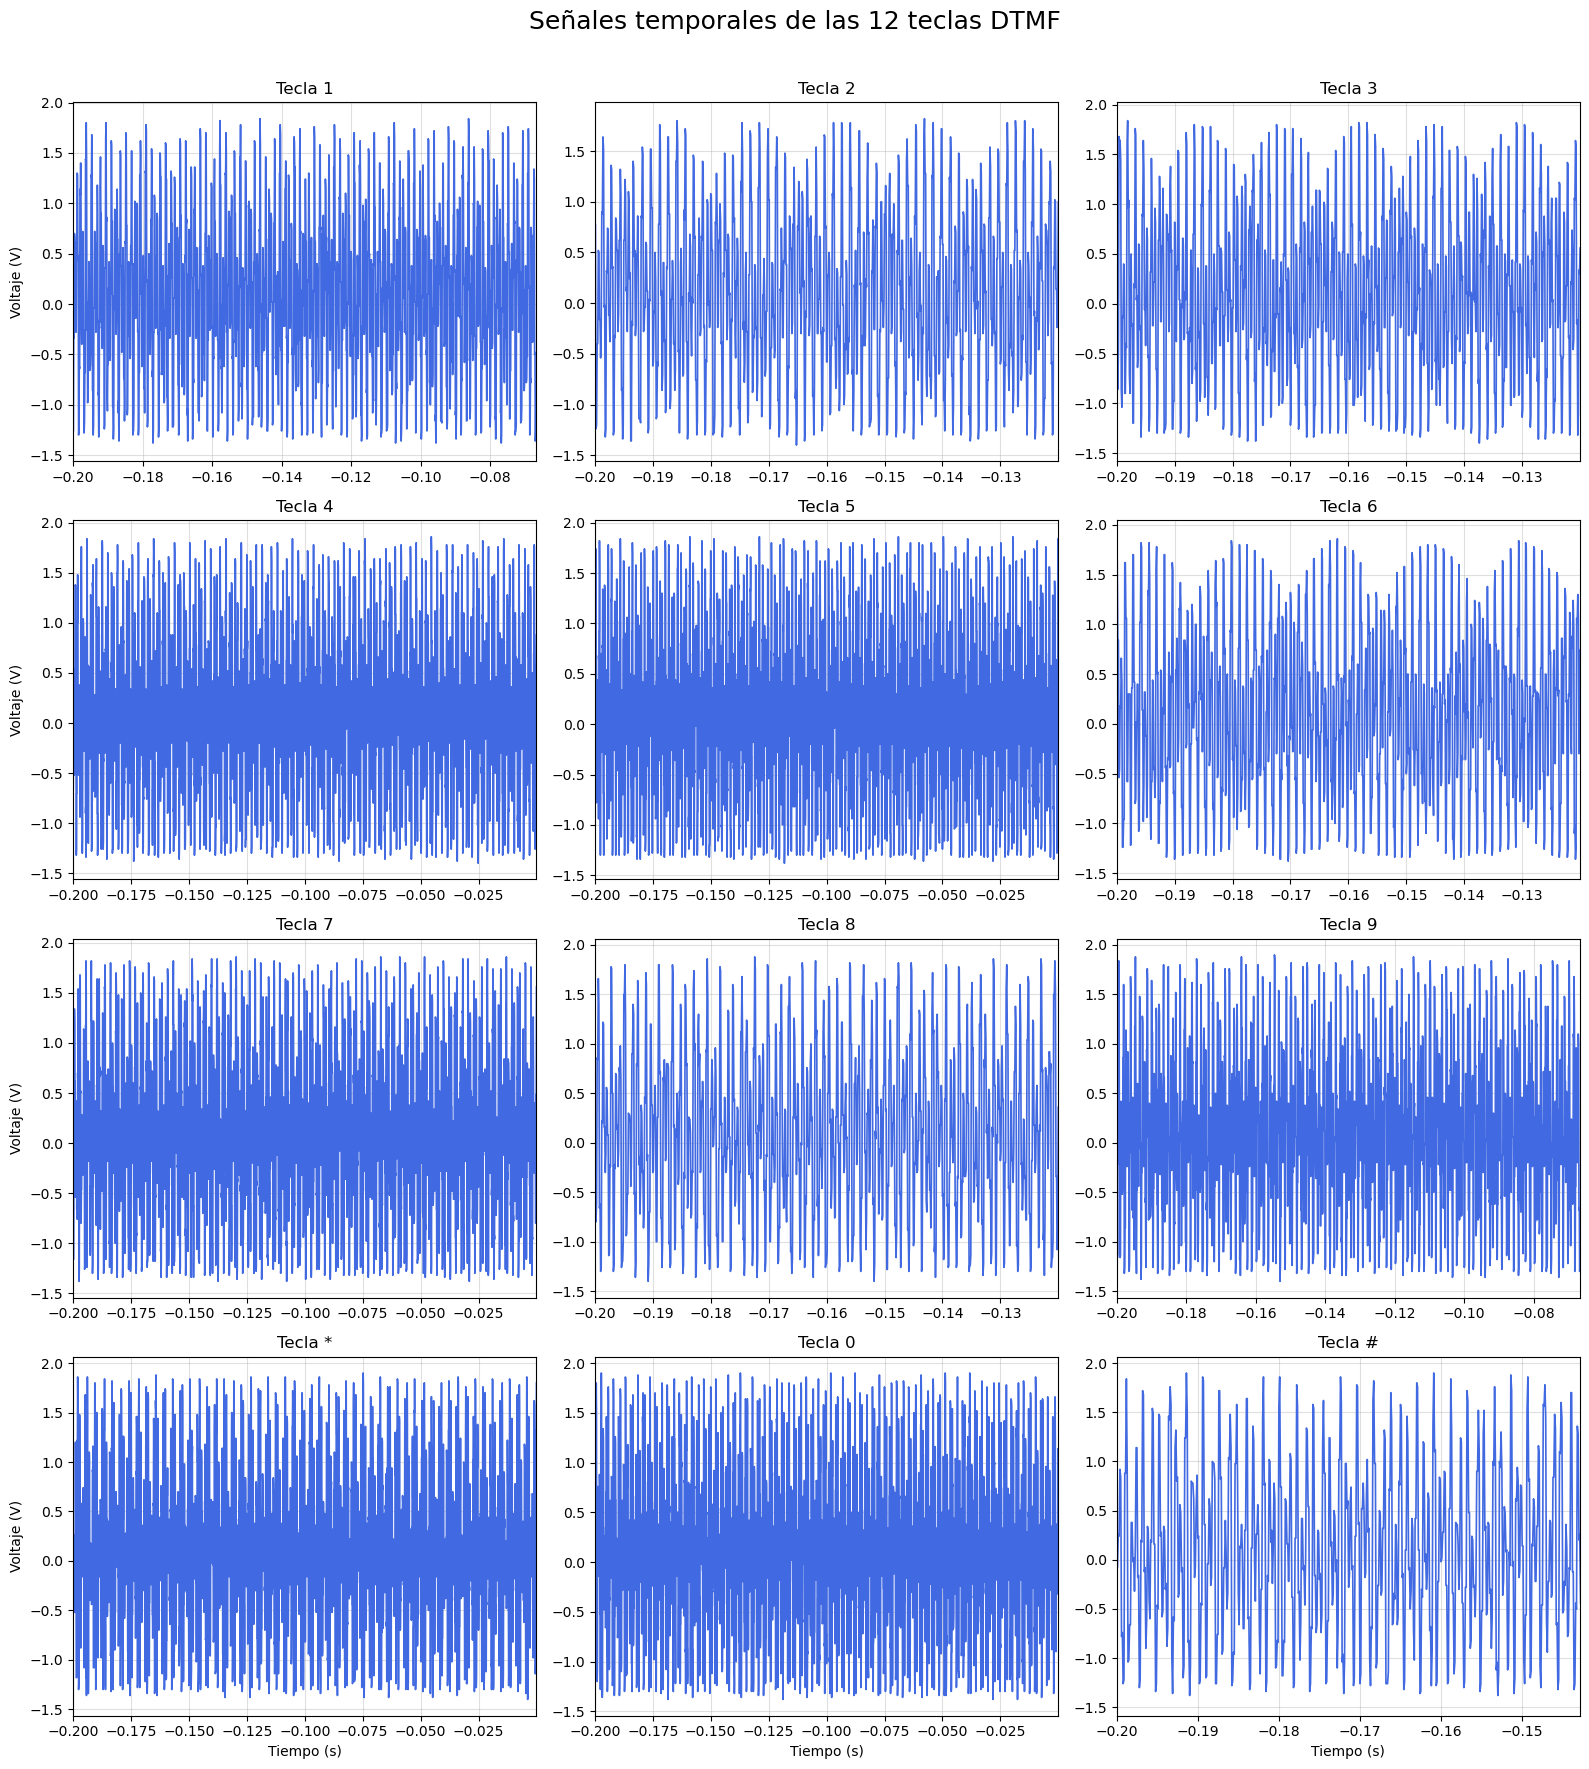

In [6]:
def graficar_senal(resultado, titulo, ax, division):

    tiempo = resultado["tiempo"]
    voltaje = resultado["voltaje"]

    ax.plot(
        tiempo,
        voltaje,
        color="royalblue",
        linewidth=1.2
    )

    # Mostrar sólo una pequeña porción para apreciar la forma de onda
    ax.set_xlim(
        tiempo[0],
        tiempo[0] + (tiempo[-1] - tiempo[0]) / division
    )

    ax.set_title(f"Tecla {titulo}", fontsize=12)
    ax.grid(True, alpha=0.4)

fig, axs = plt.subplots(
    4,
    3,
    figsize=(16, 18),
)

contador_archivo = 0

for fila, fila_teclas in enumerate(teclas):

    for columna, tecla in enumerate(fila_teclas):

        archivos = [
            f"medidas/DS{contador_archivo+i:04d}.CSV"
            for i in range(5)
        ]

        contador_archivo += 5
        division = 2
        if tecla == '1' or tecla == '9':
            division = 3
        elif tecla == '#':
            division = 7
        elif tecla == '2' or tecla == '3' or tecla == '6' or tecla == '8':
            division = 5

        #print(f"Tecla {tecla}: división = {division}")
        resultado = procesar_mediciones(archivos)

        graficar_senal(
            resultado,
            tecla,
            axs[fila, columna],
            division
        )

for ax in axs[-1, :]:
    ax.set_xlabel("Tiempo (s)")

for ax in axs[:, 0]:
    ax.set_ylabel("Voltaje (V)")

fig.suptitle(
    "Señales temporales de las 12 teclas DTMF",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Tablas

Para pasarlas al docs encontre que es mas facil copiarlo de aca, pegarlo en bloc de notas, y ahi pegarlo en excel. Hay algo en el formato que se pierde al pegarlo en bloc de notas y entonces excel no se pone mal.

### Tabla de frecuencias

In [7]:
tabla = []

for tecla, esp1, det1, esp2, det2 in resumen:

    err1 = 100 * abs(det1 - esp1) / esp1
    err2 = 100 * abs(det2 - esp2) / esp2

    tabla.append([
        tecla,
        esp1,
        round(det1, 1),
        round(err1, 2),
        esp2,
        round(det2, 1),
        round(err2, 2)
    ])

df_resumen = pd.DataFrame(
    tabla,
    columns=[
        "Tecla",
        "Esp. Bajo",
        "Det. Bajo",
        "Error (%)",
        "Esp. Alto",
        "Det. Alto",
        "Error (%)"
    ]
)

print(df_resumen)

   Tecla  Esp. Bajo  Det. Bajo  Error (%)  Esp. Alto  Det. Alto  Error (%)
0      1        697      700.0       0.43       1209     1217.5       0.70
1      2        697      700.0       0.43       1336     1332.5       0.26
2      3        697      700.0       0.43       1447     1475.0       1.94
3      4        770      767.5       0.32       1209     1217.5       0.70
4      5        770      767.5       0.32       1336     1332.5       0.26
5      6        770      767.5       0.32       1447     1475.0       1.94
6      7        852      847.5       0.53       1209     1217.5       0.70
7      8        852      847.5       0.53       1336     1332.5       0.26
8      9        852      847.5       0.53       1447     1475.0       1.94
9      *        941      950.0       0.96       1209     1217.5       0.70
10     0        941      950.0       0.96       1336     1332.5       0.26
11     #        941      950.0       0.96       1447     1475.0       1.94


### Tabla de dB

In [12]:
tabla = []

for tecla, tono_bajo_db, tono_alto_db, piso_ruido, top_picos_db, top_picos_hz, espuria_db in resumen_db:

    top_picos_hz = sorted(top_picos_hz)
    tabla.append([
        tecla,
        round(tono_bajo_db, 2),
        round(tono_alto_db, 2),
        round(piso_ruido, 2),
        round(tono_alto_db - tono_bajo_db, 2),
        round(espuria_db - tono_bajo_db, 2)
        # Falta obtener la espuria posta, que seria el quinto mayor pico de la FFT 
        # El primero y segundo mayor: los dos tonos
        # tercer y cuarto mayor: los armonicos (espurias "falsas")
        # Quinto mayor : la espuria posta que nos interesa tener para el analisis
    ])

df_db = pd.DataFrame(
    tabla,
    columns=[
        "Tecla",
        "Tono bajo (dB)",
        "Tono alto (dB)",
        "Piso de ruido (dB)",
        "Preenfasis (dB)",
        "Espuria (dB)",
    ]
)

print(df_db)

   Tecla  Tono bajo (dB)  Tono alto (dB)  Piso de ruido (dB)  Preenfasis (dB)  \
0      1           -6.67           -4.00              -52.63             2.67   
1      2           -6.76           -7.66              -49.05            -0.90   
2      3           -6.79           -5.64              -48.25             1.15   
3      4           -6.49           -4.04              -52.26             2.45   
4      5           -6.47           -7.66              -49.10            -1.19   
5      6           -6.52           -5.71              -48.31             0.81   
6      7          -10.01           -4.08              -50.23             5.92   
7      8          -10.08           -7.67              -48.56             2.41   
8      9           -9.99           -5.76              -47.95             4.23   
9      *           -6.83           -4.13              -50.05             2.71   
10     0           -6.83           -7.70              -48.12            -0.88   
11     #           -6.82    

### Tabla picos "espurias" falsos que en realidad corresponden a armonicos

In [13]:
tabla = []

for tecla, tono_bajo_db, tono_alto_db, piso_ruido, top_picos_db, top_picos_hz, espuria_db in resumen_db:

    top_picos_hz = sorted(top_picos_hz)
    tabla.append([
        tecla,
        #round(tono_bajo_db, 2),
        #round(tono_alto_db, 2),
        #round(piso_ruido, 2),
        #round(tono_alto_db - tono_bajo_db, 2),
        #round(tonos_parasitos_db[0] - tono_bajo_db, 2),
        round(top_picos_hz[0], 2),
        round(top_picos_hz[1], 2),
        round(top_picos_hz[2], 2),
        round(top_picos_hz[3], 2)
    ])

df_db = pd.DataFrame(
    tabla,
    columns=[
        "Tecla",
        "Tono bajo (dB)",
        "Tono alto (dB)",
        #"Piso de ruido (dB)",
        #"Preenfasis (dB)",
        #"Mayor espuria (dB)",
        "Tono parasito 1(db)",
        "Tono parasito 2(db)"
    ]
)

print(df_db)

   Tecla  Tono bajo (dB)  Tono alto (dB)  Tono parasito 1(db)  \
0      1           700.0          1217.5               3782.5   
1      2           700.0          1332.5               3667.5   
2      3           700.0          1475.0               3525.0   
3      4           767.5          1217.5               3782.5   
4      5           767.5          1332.5               3667.5   
5      6           767.5          1475.0               3525.0   
6      7           847.5          1217.5               3782.5   
7      8           847.5          1332.5               3667.5   
8      9           847.5          1475.0               3525.0   
9      *           950.0          1217.5               3782.5   
10     0           950.0          1332.5               3667.5   
11     #           950.0          1475.0               3525.0   

    Tono parasito 2(db)  
0                4300.0  
1                4300.0  
2                4300.0  
3                4232.5  
4                4232.5 